In [10]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt

print("Done!")

Done!


In [2]:
df=pd.read_csv("StudentPerformanceFactors.csv")

In [3]:
print(df.head())
print(df.shape)
print(df.columns)
print(df.info())
print(df.describe())
print(df.isnull().sum())

   Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
0             23          84                  Low                High   
1             19          64                  Low              Medium   
2             24          98               Medium              Medium   
3             29          89                  Low              Medium   
4             19          92               Medium              Medium   

  Extracurricular_Activities  Sleep_Hours  Previous_Scores Motivation_Level  \
0                         No            7               73              Low   
1                         No            8               59              Low   
2                        Yes            7               91           Medium   
3                        Yes            8               98           Medium   
4                        Yes            6               65           Medium   

  Internet_Access  Tutoring_Sessions Family_Income Teacher_Quality  \
0             Ye

In [4]:
print("Duplicate rows:",df.duplicated().sum())

Duplicate rows: 0


In [5]:
print("Scores above 100:",(df["Exam_Score"]>100).sum())
print(df[df["Exam_Score"]>100])

Scores above 100: 1
      Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
1525             27          98                  Low              Medium   

     Extracurricular_Activities  Sleep_Hours  Previous_Scores  \
1525                        Yes            6               93   

     Motivation_Level Internet_Access  Tutoring_Sessions Family_Income  \
1525              Low              No                  5          High   

     Teacher_Quality School_Type Peer_Influence  Physical_Activity  \
1525            High      Public       Positive                  3   

     Learning_Disabilities Parental_Education_Level Distance_from_Home  \
1525                    No              High School           Moderate   

      Gender  Exam_Score  
1525  Female         101  


In [8]:
categorical_columns=df.select_dtypes(include="object").columns

for column in categorical_columns:
    print(df[column].value_counts(dropna=False))
    print("\n")

Parental_Involvement
Medium    3362
High      1908
Low       1337
Name: count, dtype: int64


Access_to_Resources
Medium    3319
High      1975
Low       1313
Name: count, dtype: int64


Extracurricular_Activities
Yes    3938
No     2669
Name: count, dtype: int64


Motivation_Level
Medium    3351
Low       1937
High      1319
Name: count, dtype: int64


Internet_Access
Yes    6108
No      499
Name: count, dtype: int64


Family_Income
Low       2672
Medium    2666
High      1269
Name: count, dtype: int64


Teacher_Quality
Medium    3925
High      1947
Low        657
NaN         78
Name: count, dtype: int64


School_Type
Public     4598
Private    2009
Name: count, dtype: int64


Peer_Influence
Positive    2638
Neutral     2592
Negative    1377
Name: count, dtype: int64


Learning_Disabilities
No     5912
Yes     695
Name: count, dtype: int64


Parental_Education_Level
High School     3223
College         1989
Postgraduate    1305
NaN               90
Name: count, dtype: int64


Distance

C:\Users\user\AppData\Local\Temp\ipykernel_27348\584555212.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns=df.select_dtypes(include="object").columns


In [11]:
df=df[df["Exam_Score"]<=100]
print(df.shape)
print(df["Exam_Score"].max())

(6606, 20)
100


In [12]:
numeric_columns=df.select_dtypes(include="number")
print(numeric_columns.corr()["Exam_Score"].sort_values(ascending=False))
print(df["Exam_Score"].value_counts().sort_index())

Exam_Score           1.000000
Attendance           0.582458
Hours_Studied        0.446514
Previous_Scores      0.174461
Tutoring_Sessions    0.153754
Physical_Activity    0.027943
Sleep_Hours         -0.016194
Name: Exam_Score, dtype: float64
Exam_Score
55       1
56       1
57       4
58      22
59      40
60      77
61     171
62     264
63     371
64     501
65     679
66     751
67     717
68     759
69     624
70     542
71     408
72     304
73     141
74     106
75      48
76      16
77       5
78       4
79       3
80       5
82       4
83       1
84       3
85       1
86       4
87       2
88       3
89       3
91       1
92       2
93       2
94       4
95       2
96       1
97       3
98       3
99       2
100      1
Name: count, dtype: int64


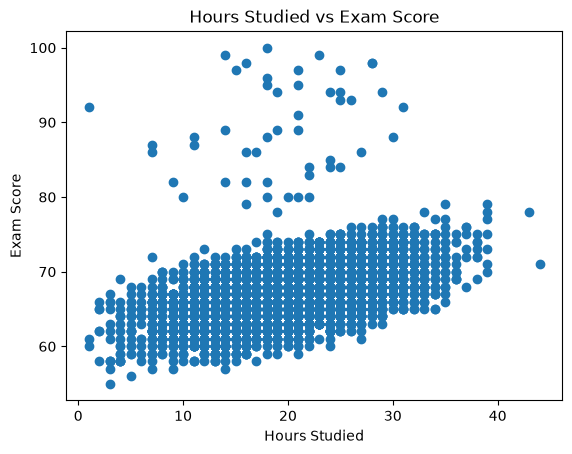

In [13]:
plt.scatter(df["Hours_Studied"],df["Exam_Score"])
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.title("Hours Studied vs Exam Score")
plt.show()

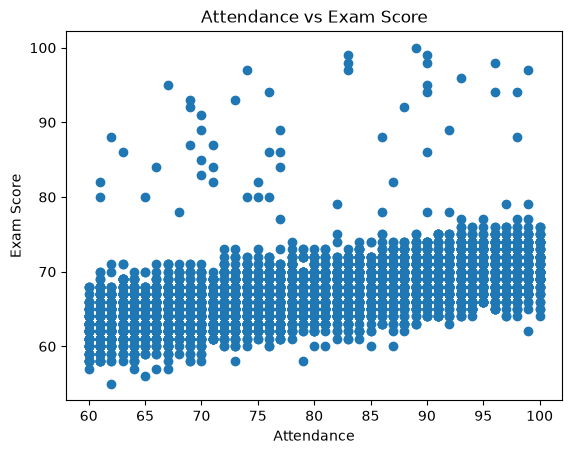

In [14]:
plt.scatter(df["Attendance"], df["Exam_Score"])
plt.xlabel("Attendance")
plt.ylabel("Exam Score")
plt.title("Attendance vs Exam Score")
plt.show()

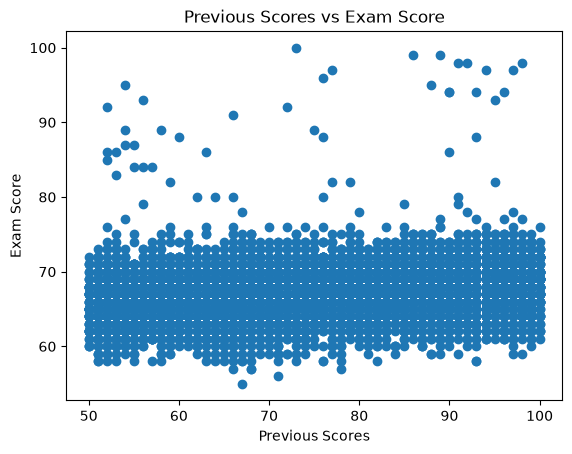

In [15]:
plt.scatter(df["Previous_Scores"], df["Exam_Score"])
plt.xlabel("Previous Scores")
plt.ylabel("Exam Score")
plt.title("Previous Scores vs Exam Score")
plt.show()

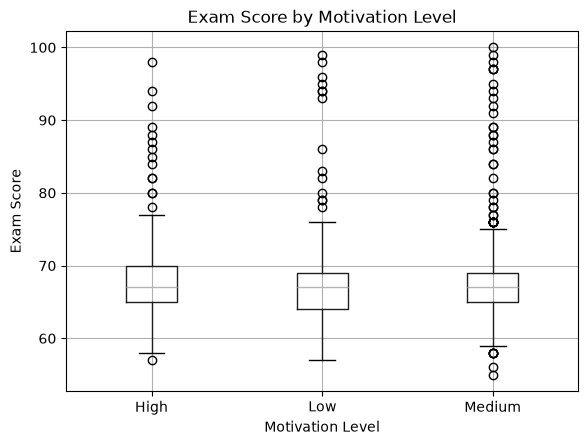

In [16]:
df.boxplot(column="Exam_Score", by="Motivation_Level")
plt.title("Exam Score by Motivation Level")
plt.suptitle("")
plt.xlabel("Motivation Level")
plt.ylabel("Exam Score")
plt.show()

In [17]:
print(df.shape)
print(df.isnull().sum())

(6606, 20)
Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64


PREPROCESSING

In [18]:
X=df.drop(columns=["Exam_Score"])
y=df["Exam_Score"]
print("Features shape:",X.shape)
print("Target shape:",y.shape)

Features shape: (6606, 19)
Target shape: (6606,)


In [19]:
numerical_features=X.select_dtypes(include="number").columns
categorical_features=X.select_dtypes(include="str").columns
print("Numerical features:")
print(list(numerical_features))
print("\nCategorical features:")
print(list(categorical_features))

Numerical features:
['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity']

Categorical features:
['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']


In [21]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test= train_test_split(X,y,test_size=0.2,random_state=42)
print("Training data:",X_train.shape)
print("Testing data:",X_test.shape)

Training data: (5284, 19)
Testing data: (1322, 19)


In [22]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

categorical_transformer=Pipeline(steps=[
    ("imputer",SimpleImputer(strategy="most_frequent")),
    ("encoder",OneHotEncoder(handle_unknown="ignore"))
])
preprocessor=ColumnTransformer(transformers=[("categorical",categorical_transformer,categorical_features)],remainder="passthrough")

1st model: LINEAR REGRESSION

In [23]:
from sklearn.linear_model import LinearRegression
linear_model=Pipeline(steps=[("preprocessor",preprocessor),("model",LinearRegression())])
linear_model.fit(X_train,y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['Hours_Studied','Attendance','Parental_Involvement',..., 'Parental_Education_Level','Distance_from_Home','Gender']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically 

In [24]:
y_pred_linear=linear_model.predict(X_test)

In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae_linear=mean_absolute_error(y_test,y_pred_linear)
mse_linear=mean_squared_error(y_test,y_pred_linear)
rmse_linear=mean_squared_error(y_test,y_pred_linear)**0.5
r2_linear=r2_score(y_test,y_pred_linear)
print("Linear Regression Results:")
print("MAE:",mae_linear)
print("MSE:",mse_linear)
print("RMSE:",rmse_linear)
print("R²:",r2_linear)

Linear Regression Results:
MAE: 0.4159761177572455
MSE: 2.314239627149146
RMSE: 1.521262510926088
R²: 0.8249999018449949


In [26]:
from sklearn.ensemble import RandomForestRegressor

random_forest_model=Pipeline(steps=[
    ("preprocessor",preprocessor),("model",RandomForestRegressor(n_estimators=100, random_state=42,n_jobs=-1))
])
random_forest_model.fit(X_train,y_train)
y_pred_rf=random_forest_model.predict(X_test)

In [27]:
mae_rf=mean_absolute_error(y_test,y_pred_rf)
mse_rf=mean_squared_error(y_test,y_pred_rf)
rmse_rf=mean_squared_error(y_test,y_pred_rf)**0.5
r2_rf=r2_score(y_test,y_pred_rf)
print("Random Forest Results:")
print("MAE:",mae_rf)
print("MSE:",mse_rf)
print("RMSE:",rmse_rf)
print("R²:",r2_rf)

Random Forest Results:
MAE: 1.0713313161875944
MSE: 3.9273363086232975
RMSE: 1.981750819004069
R²: 0.7030194144832613


In [28]:
print(X_train.dtypes)
print(X_train.shape)
print(X_test.shape)

Hours_Studied                 int64
Attendance                    int64
Parental_Involvement            str
Access_to_Resources             str
Extracurricular_Activities      str
Sleep_Hours                   int64
Previous_Scores               int64
Motivation_Level                str
Internet_Access                 str
Tutoring_Sessions             int64
Family_Income                   str
Teacher_Quality                 str
School_Type                     str
Peer_Influence                  str
Physical_Activity             int64
Learning_Disabilities           str
Parental_Education_Level        str
Distance_from_Home              str
Gender                          str
dtype: object
(5284, 19)
(1322, 19)


In [29]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae_linear, mae_rf],
    "MSE": [mse_linear, mse_rf],
    "RMSE": [rmse_linear, rmse_rf],
    "R²": [r2_linear, r2_rf]
})

comparison

,Model,MAE,MSE,RMSE,R²
0,Linear Regression,0.415976,2.314240,1.521263,0.825000
1,Random Forest,1.071331,3.927336,1.981751,0.703019


In [30]:
results=pd.DataFrame({"Actual":y_test.values,"Predicted_linear":y_pred_linear})
results.head(10)

,Actual,Predicted_linear
0,66,66.014587
1,66,65.445139
2,67,67.578929
3,67,67.650863
4,68,68.005283
5,63,63.253303
6,74,74.013600
7,65,65.074757
8,69,68.969310
9,76,75.709522


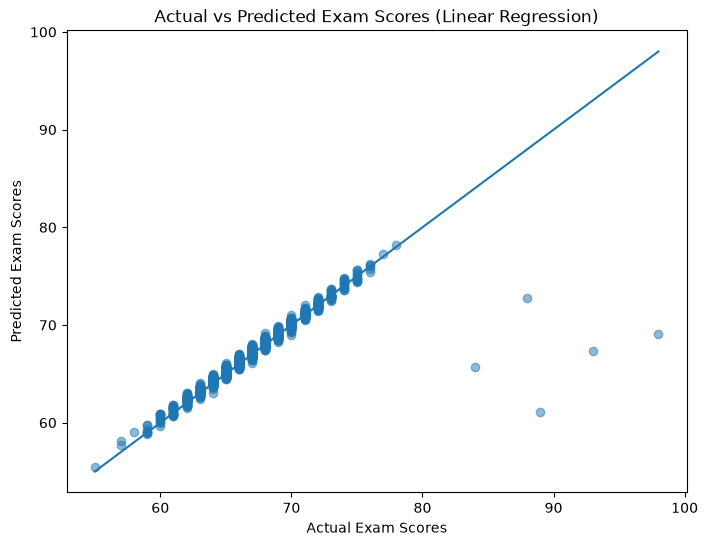

In [31]:
plt.figure(figsize=(8,6))
plt.scatter(y_test,y_pred_linear,alpha=0.5)
plt.xlabel("Actual Exam Scores")
plt.ylabel("Predicted Exam Scores")
plt.title("Actual vs Predicted Exam Scores (Linear Regression)")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])  # Diagonal line
plt.show()

In [32]:
residuals=y_test-y_pred_linear
print(residuals.describe())

count    1322.000000
mean       -0.098385
std         1.518652
min        -1.141688
25%        -0.464142
50%        -0.184332
75%         0.091205
max        28.957439
Name: Exam_Score, dtype: float64


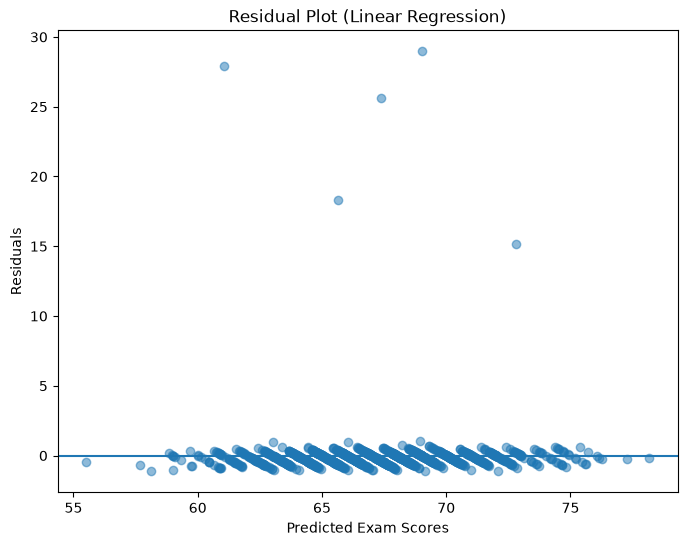

In [33]:
plt.figure(figsize=(8,6))
plt.scatter(y_pred_linear,residuals,alpha=0.5)
plt.axhline(y=0)
plt.xlabel("Predicted Exam Scores")
plt.ylabel("Residuals")
plt.title("Residual Plot (Linear Regression)")
plt.show()

In [34]:
results=X_test.copy()
results["Actual"]=y_test
results["Predicted_Linear"]=y_pred_linear
results["Residual"]=residuals
results["Absolute_Error"]=results["Residual"].abs()

results.sort_values(by="Absolute_Error",ascending=False).head(10)

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Actual,Predicted_Linear,Residual,Absolute_Error
6393,16,83,Low,Medium,Yes,8,92,Low,Yes,2,...,Positive,4,No,Postgraduate,Near,Female,98,69.042561,28.957439,28.957439
217,19,70,Medium,Low,No,7,54,High,Yes,0,...,Positive,2,Yes,High School,Moderate,Male,89,61.052321,27.947679,27.947679
4583,25,73,Medium,Medium,Yes,7,56,Medium,Yes,2,...,Neutral,4,No,High School,Near,Female,93,67.373495,25.626505,25.626505
3932,25,66,High,Medium,Yes,7,55,Medium,Yes,4,...,Neutral,2,Yes,High School,Moderate,Female,84,65.661046,18.338954,18.338954
1607,30,98,Medium,Low,Yes,9,93,Medium,Yes,1,...,Positive,3,No,High School,Near,Male,88,72.812260,15.187740,15.187740
5160,22,74,High,High,Yes,5,99,Medium,Yes,0,...,Neutral,2,No,College,Near,Female,68,69.141688,-1.141688,1.141688
2880,7,66,High,Low,Yes,8,68,High,Yes,0,...,Negative,2,Yes,College,Moderate,Male,57,58.137661,-1.137661,1.137661
1393,21,98,High,Medium,Yes,10,95,Medium,Yes,0,...,Neutral,1,No,High School,NaN,Male,71,72.079500,-1.079500,1.079500
5020,20,65,High,Medium,Yes,8,71,Low,Yes,2,...,Neutral,3,Yes,College,Near,Female,63,64.067804,-1.067804,1.067804
2118,5,89,Medium,Medium,Yes,4,76,High,Yes,2,...,Neutral,3,No,College,Near,Male,65,66.059913,-1.059913,1.059913
